In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df = pd.read_csv("Hospital Dataset.csv")

df.head()

,STATISTIC,Statistic Label,TLIST(A1),Year,C02199V02655,Sex,C02857V03435,Type of Procedure,C02076V02508,Age Group,UNIT,VALUE
0,DHA102C01,Inpatient Bed Days,2017,2017,-,Both sexes,100,Procedures on nervous system,215,0 - 14 years,Number,8940.0
1,DHA102C01,Inpatient Bed Days,2017,2017,-,Both sexes,100,Procedures on nervous system,310,15 - 24 years,Number,4212.0
2,DHA102C01,Inpatient Bed Days,2017,2017,-,Both sexes,100,Procedures on nervous system,415,25 - 34 years,Number,7714.0
3,DHA102C01,Inpatient Bed Days,2017,2017,-,Both sexes,100,Procedures on nervous system,465,35 - 44 years,Number,8924.0
4,DHA102C01,Inpatient Bed Days,2017,2017,-,Both sexes,100,Procedures on nervous system,500,45 - 54 years,Number,11523.0


In [25]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 13681 entries, 0 to 19679
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         13681 non-null  int64  
 1   VALUE                        13681 non-null  float64
 2   Sex_Both sexes               13681 non-null  bool   
 3   Sex_Female                   13681 non-null  bool   
 4   Sex_Male                     13681 non-null  bool   
 5   Age Group_0 - 14 years       13681 non-null  bool   
 6   Age Group_15 - 24 years      13681 non-null  bool   
 7   Age Group_25 - 34 years      13681 non-null  bool   
 8   Age Group_35 - 44 years      13681 non-null  bool   
 9   Age Group_45 - 54 years      13681 non-null  bool   
 10  Age Group_55 - 64 years      13681 non-null  bool   
 11  Age Group_65 - 74 years      13681 non-null  bool   
 12  Age Group_75 - 84 years      13681 non-null  bool   
 13  Age Group_85 years an

,Year,VALUE
count,13681.000000,1.368100e+04
mean,2020.479132,1.615900e+04
std,2.305573,1.134549e+05
min,2017.000000,0.000000e+00
25%,2018.000000,1.180000e+02
50%,2020.000000,6.200000e+02
75%,2023.000000,3.119000e+03
max,2024.000000,3.544582e+06


In [27]:
df['Year'] = df['Year'].astype(int)

In [28]:
df.duplicated().sum()

np.int64(707)

In [29]:
df = df.drop_duplicates()

In [9]:
df = df.dropna()

In [61]:
data = df[['Year','Age Group','Sex','VALUE']]
data.head()

,Year,Age Group,Sex,VALUE
0,2017,0 - 14 years,Both sexes,8940.0
1,2017,15 - 24 years,Both sexes,4212.0
2,2017,25 - 34 years,Both sexes,7714.0
3,2017,35 - 44 years,Both sexes,8924.0
4,2017,45 - 54 years,Both sexes,11523.0


In [10]:
df = pd.get_dummies(df, columns=['Sex','Age Group'])

In [11]:
X = df.drop('VALUE', axis=1)
y = df['VALUE']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [13]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [46]:
print(df.columns)

Index(['Year', 'VALUE', 'Sex_Both sexes', 'Sex_Female', 'Sex_Male',
       'Age Group_0 - 14 years', 'Age Group_15 - 24 years',
       'Age Group_25 - 34 years', 'Age Group_35 - 44 years',
       'Age Group_45 - 54 years', 'Age Group_55 - 64 years',
       'Age Group_65 - 74 years', 'Age Group_75 - 84 years',
       'Age Group_85 years and over', 'Age Group_All ages'],
      dtype='object')


In [47]:
df.columns = df.columns.str.strip()

In [65]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, pred_lr))
print("MSE:", mean_squared_error(y_test, pred_lr))
print("R2 Score:", r2_score(y_test, pred_lr))

Linear Regression Results
MAE: 25171.117458949644
MSE: 13596174793.563187
R2 Score: 0.027743903940352532


In [35]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [33]:
print("Random Forest Results")

print("MAE:", mean_absolute_error(y_test, pred_rf))
print("MSE:", mean_squared_error(y_test, pred_rf))
print("R2 Score:", r2_score(y_test, pred_rf))

Random Forest Results
MAE: 25319.84379789901
MSE: 14010907970.738287
R2 Score: -0.0019134714515538498


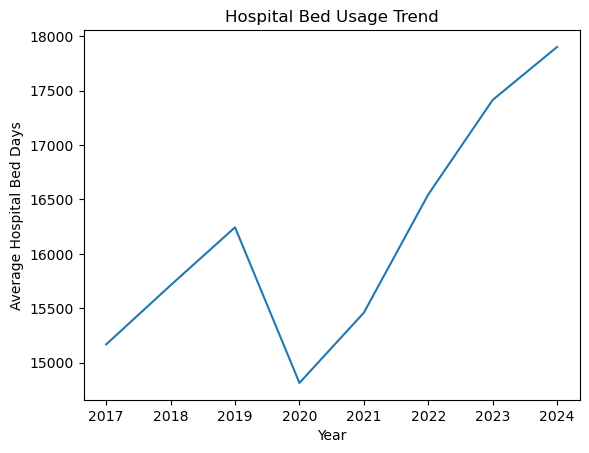

In [17]:
yearly = df.groupby('Year')['VALUE'].mean().reset_index()

plt.figure()

plt.plot(yearly['Year'], yearly['VALUE'])

plt.xlabel("Year")
plt.ylabel("Average Hospital Bed Days")

plt.title("Hospital Bed Usage Trend")

plt.show()

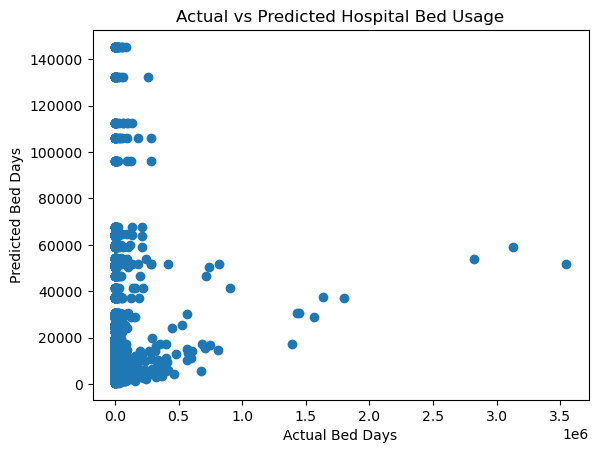

In [18]:
plt.figure()

plt.scatter(y_test, pred_rf)

plt.xlabel("Actual Bed Days")
plt.ylabel("Predicted Bed Days")

plt.title("Actual vs Predicted Hospital Bed Usage")

plt.show()

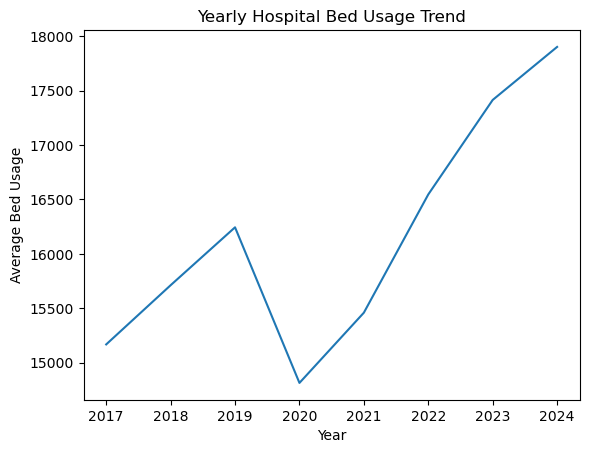

In [36]:
plt.figure()

plt.plot(yearly['Year'], yearly['VALUE'])

plt.xlabel("Year")
plt.ylabel("Average Bed Usage")

plt.title("Yearly Hospital Bed Usage Trend")

plt.show()

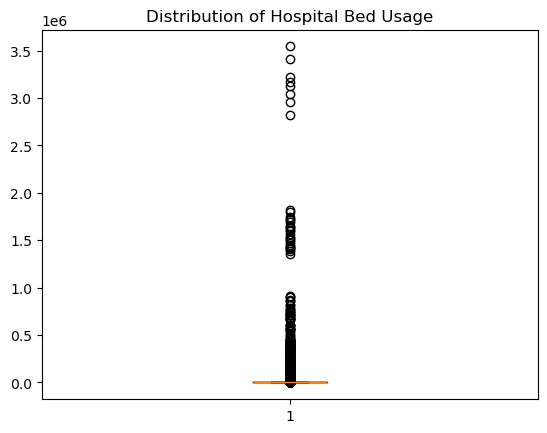

In [38]:
plt.figure()

plt.boxplot(df['VALUE'])

plt.title("Distribution of Hospital Bed Usage")

plt.show()

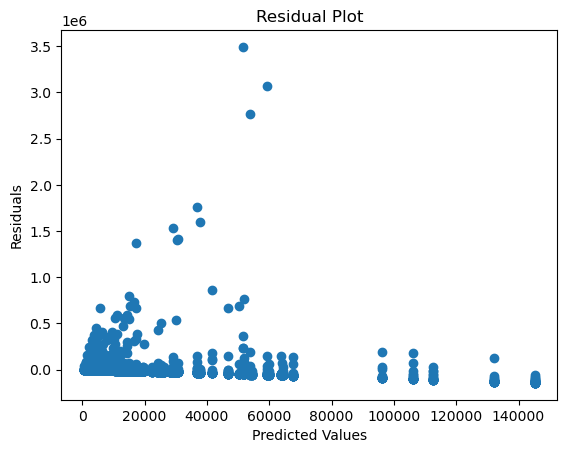

In [40]:
residuals = y_test - pred_rf

plt.figure()

plt.scatter(pred_rf, residuals)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Index(['STATISTIC', 'Statistic Label', 'TLIST(A1)', 'Year', 'C02199V02655',
       'Sex', 'C02857V03435', 'Type of Procedure', 'C02076V02508', 'Age Group',
       'UNIT', 'VALUE'],
      dtype='object')
           Age Group         VALUE
0       0 - 14 years   5323.694370
1      15 - 24 years   2513.791701
2      25 - 34 years   5591.002338
3      35 - 44 years   5945.793914
4      45 - 54 years   5407.401077
5      55 - 64 years   8974.856851
6      65 - 74 years  14754.373333
7      75 - 84 years  19436.464469
8  85 years and over  14758.476856
9           All ages  64451.071678


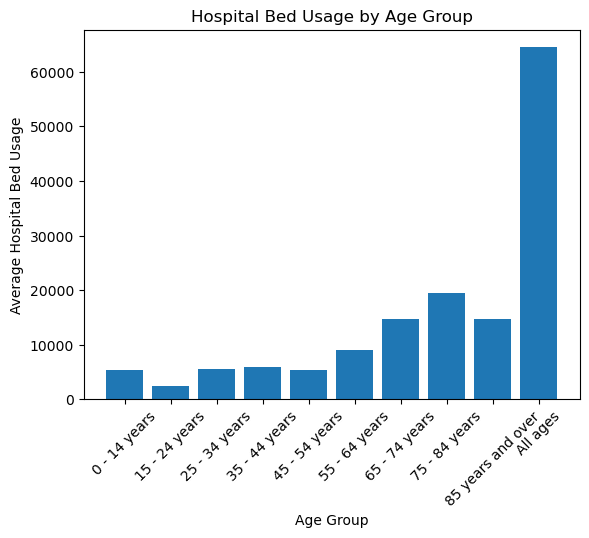

In [53]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("Hospital Dataset.csv")


df.columns = df.columns.str.strip()


print(df.columns)


age_data = df.groupby('Age Group')['VALUE'].mean().reset_index()

print(age_data)


plt.figure()

plt.bar(age_data['Age Group'], age_data['VALUE'])

plt.xlabel("Age Group")
plt.ylabel("Average Hospital Bed Usage")
plt.title("Hospital Bed Usage by Age Group")

plt.xticks(rotation=45)

plt.show()

In [66]:
plt.figure(figsize=(10,6))

plt.plot(yearly_beds['Year'], yearly_beds['Bed_Days'], label="Historical Data", marker='o')

plt.plot(future_years['Year'], future_years['Predicted_Bed_Days'], 
         label="Forecast", marker='o', linestyle='--')

plt.xlabel("Year")
plt.ylabel("Bed Days")
plt.title("Forecast of Hospital Bed Demand")
plt.legend()
plt.grid(True)

plt.show()

<Figure size 1000x600 with 0 Axes>

<class 'NameError'>: name 'yearly_beds' is not defined